# Examen final
### Análisis de dataset de imágenes MRI cerebrales

Este proyecto analizará 40.000 imágenes IRM cerebrales para poder entrenar un modelo de regresión lineal el cual predicirá, dados los datos extraídos de una imagen, si un paciente tiene alzheimers o no.

Para esto, se necesitará:
- Obtener el dataset desde Kaggle
- Transformar datos de imágenes a datos en csv, obteniendo toda la información relevante 
- Agrupar los csv en un DataFrame
- Entrenar y probar un modelo de regresión lineal para predecir si un paciente tiene alzheimers o no, y que tan severo es. 

### Importación

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install kagglehub
%pip install numpy
%pip install stats

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/e9/a5/1be1516390333ff9be3a9cb648c9f33df79d5096e5884b5df71a588af463/opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata
  Obtaining dependency information for numpy>=2 from https://files.pythonhosted.org/packages/f0/66/d215f3fb93541617adb5d58b3b9508e8a6413e499711e0adc0b80bcb445d/numpy-2.4.5-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB 653.6 kB/s eta 0:01:02
   ---------------------------------------- 0.2/40.2 MB 1.8 MB/s eta 0:00:22
    --------------------------------------- 0.9/40.2 MB 6.4 MB/s eta 0:00:07
   - -------------------------------------- 1.8/40.2 MB 10.7 MB/s eta 0:00:04
   -- ------------------------------------- 2.5/40.2 MB 11.5 MB/s eta 0:00:04
   --- ------------------------------------ 3.2/40.2 MB 12.1 MB/s eta 0:00:04
   --- ---------------------------

ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'C:\\Python311\\Scripts\\f2py.exe' -> 'C:\\Python311\\Scripts\\f2py.exe.deleteme'



https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset

In [ ]:
import kagglehub
# descargar a la misma carpeta:
kagglehub.dataset_download("uraninjo/augmented-alzheimer-mri-dataset", output_dir='Datos')

KeyboardInterrupt: 

In [12]:
import pandas as pd
import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Tenemos los datos, pero no podemos usarlos todavia dado que nuestras herramientas no incluyen librerías como tensorflow que puedan trabajar con imágenes.

Primero, debemos definir que parte de cada imagen es que. Debemos definir que parte es:
- Fluido cerebroespinal
- Materia gris
- Materia blanca
En cada imagen. 

Para esto, usaremos Pillow. Sin embargo, debemos también entender que no existen rangos específicos universales para la escala de grises que usaremos para extraer las características necesarias de las imágenes.

Entonces primero que todo, debemos nosotros mismos investigar que rango correspondería a este dataset.

In [8]:
!pip install opencv-python==4.8.1.78

  Obtaining dependency information for opencv-python==4.8.1.78 from https://files.pythonhosted.org/packages/38/d2/3e8c13ffc37ca5ebc6f382b242b44acb43eb489042e1728407ac3904e72f/opencv_python-4.8.1.78-cp37-abi3-win_amd64.whl.metadata
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB 660.6 kB/s eta 0:00:58
   ---------------------------------------- 0.1/38.1 MB 1.1 MB/s eta 0:00:37
    --------------------------------------- 0.5/38.1 MB 4.2 MB/s eta 0:00:09
   - -------------------------------------- 1.0/38.1 MB 6.6 MB/s eta 0:00:06
   - -------------------------------------- 1.0/38.1 MB 6.6 MB/s eta 0:00:06
   - -------------------------------------- 1.5/38.1 MB 5.5 MB/s eta 0:00:07
   -- ------------------------------------- 2.1/38.1 MB 7.0 MB/s eta 0:00:06
   -- ------------------------------------- 2.1/38.1 MB 7.0 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/38.1 MB 6.5 MB/s eta 0:00:06
   -

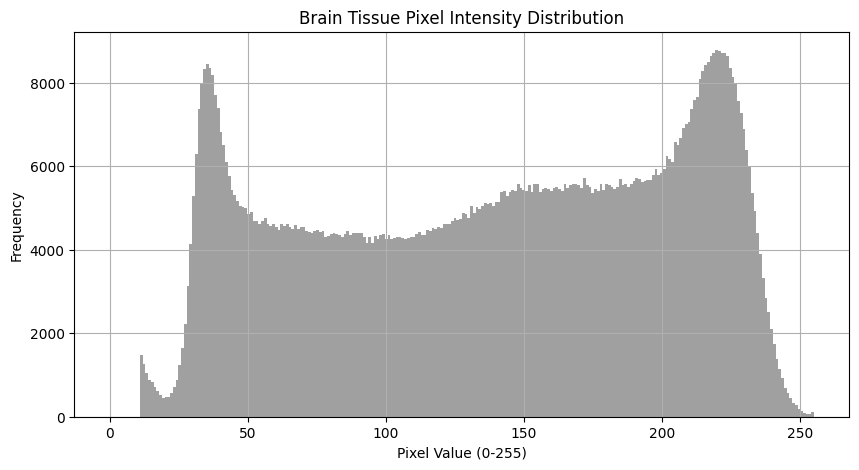

In [ ]:
import os
from PIL import Image
import cv2
# Primero, veremos como los datos se ven en un histograma.
# Analizemos cada pixel, en todos las carpetas, por un for loop [TODO]
DATASET_DIR = "./Datos/OriginalDataset/ModerateDemented"
sample_files = os.listdir(DATASET_DIR)[:200]  # Tomar 50 imagenes como muestra

all_pixels = []

for file in sample_files:
    if file.endswith('.jpg'):
        img = cv2.imread(os.path.join(DATASET_DIR, file), cv2.IMREAD_GRAYSCALE)
        pixels = img[img > 10].flatten() 
        all_pixels.extend(pixels)

# Plot the distribution
plt.figure(figsize=(10, 5))
plt.hist(all_pixels, bins=256, range=(0, 255), color='gray', alpha=0.75)
plt.title("Brain Tissue Pixel Intensity Distribution")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()